# Iris Flower Classification using Machine Learning

## Import Libraries

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings

import warnings
warnings.filterwarnings('ignore')

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv("Iris.csv")

# Display first 5 rows

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Dataset Overview 

In [3]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
# Statistical Summary

df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Missing values check

In [5]:
# Check Missing Values

df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## Duplicate values check

In [6]:
# Check Duplicates

df.duplicated().sum()

0

In [7]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

print(df.shape)

(150, 6)


## Drop Unnecessary Column

In [8]:
# Remove ID Column

df.drop('Id', axis=1, inplace=True)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Exploratory Data Analysis (EDA)
### Specied Distribution

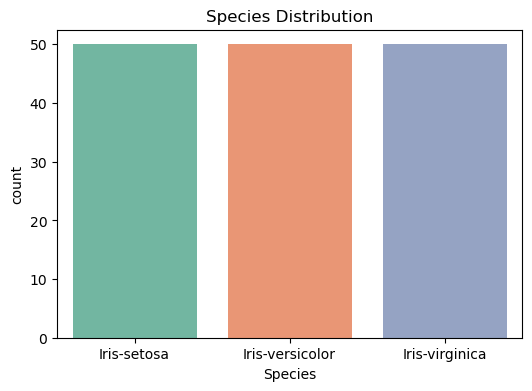

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Species',
    data=df,
    palette='Set2',
)

plt.title("Species Distribution")

plt.show()

#### Observation
- Dataset is balanced.
- All species have almost equal samples.

### Pairplot

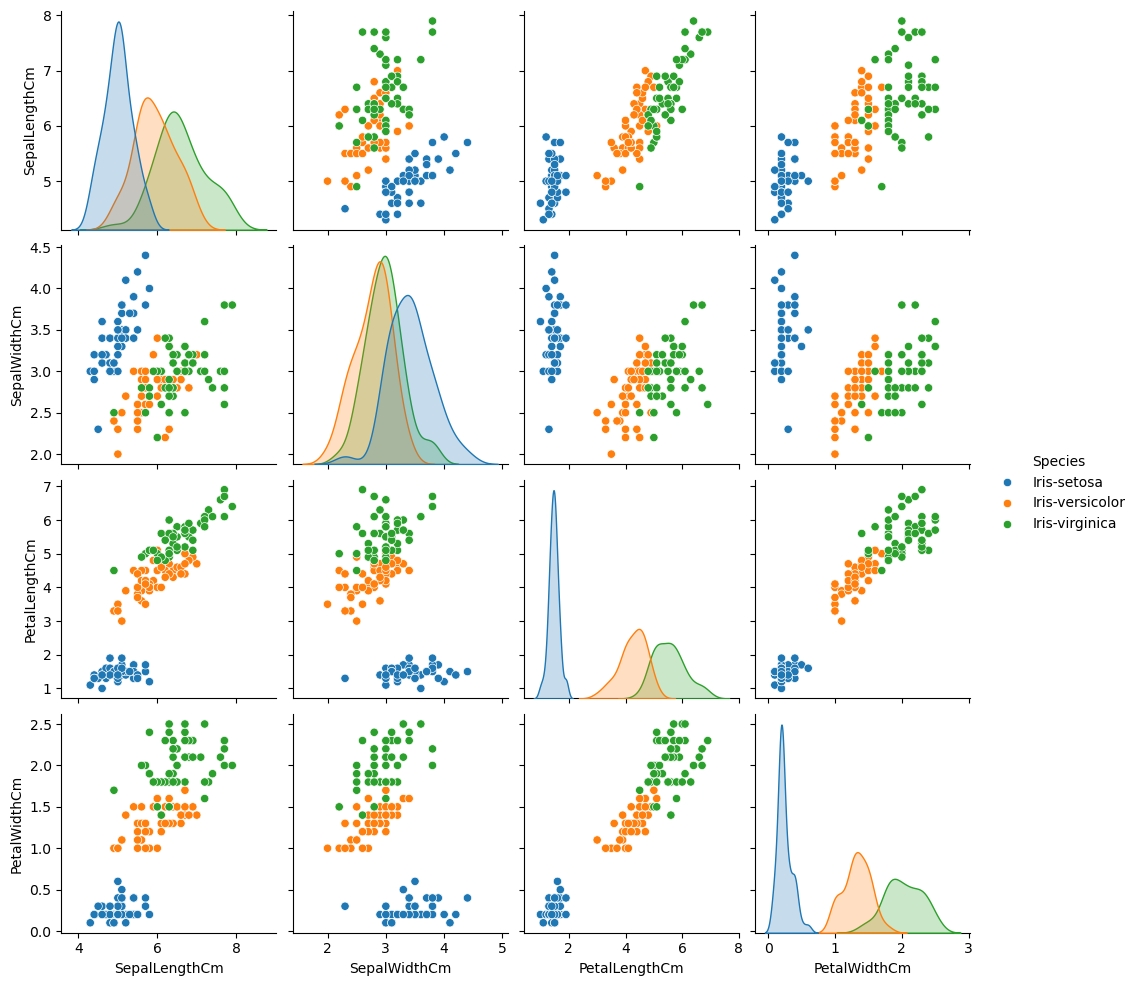

In [10]:
sns.pairplot(
    df,
    hue='Species'
)

plt.show()

#### Observation
- Species are separable using petal measurements.

### Sepal Length Distributuin

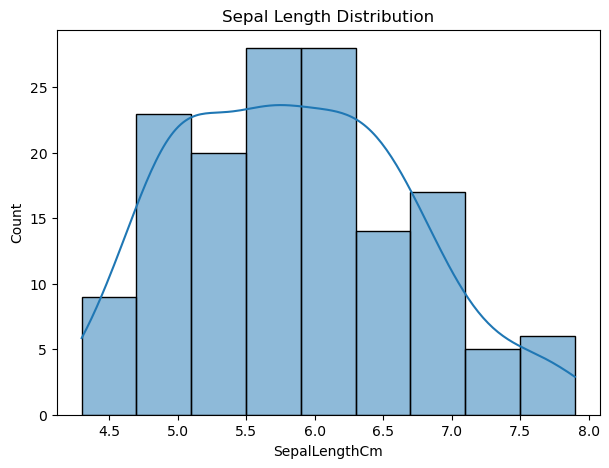

In [11]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['SepalLengthCm'],
    kde=True
)

plt.title("Sepal Length Distribution")

plt.show()

### Petal Length Distribution

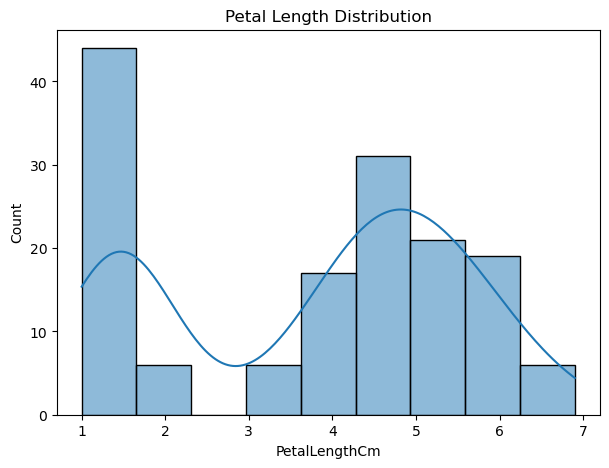

In [12]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['PetalLengthCm'],
    kde=True
)

plt.title("Petal Length Distribution")

plt.show()

### Petsl length vs Petal Width

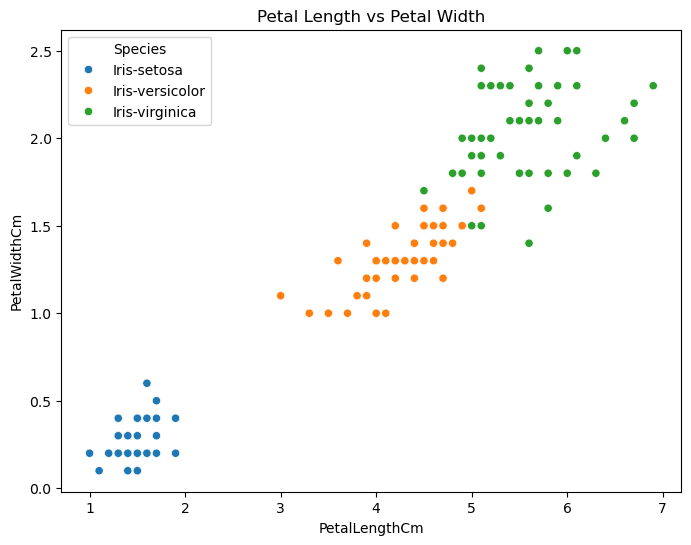

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    data=df
)

plt.title("Petal Length vs Petal Width")

plt.show()

#### Observation
- Clear separation exists among species.

### Species Vs Petal Length

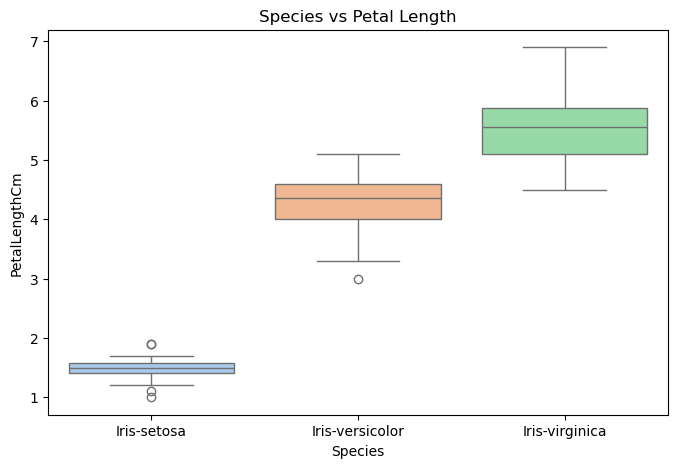

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Species',
    y='PetalLengthCm',
    data=df,
    palette='pastel',
)

plt.title("Species vs Petal Length")

plt.show()

### Species Vs Petal Width

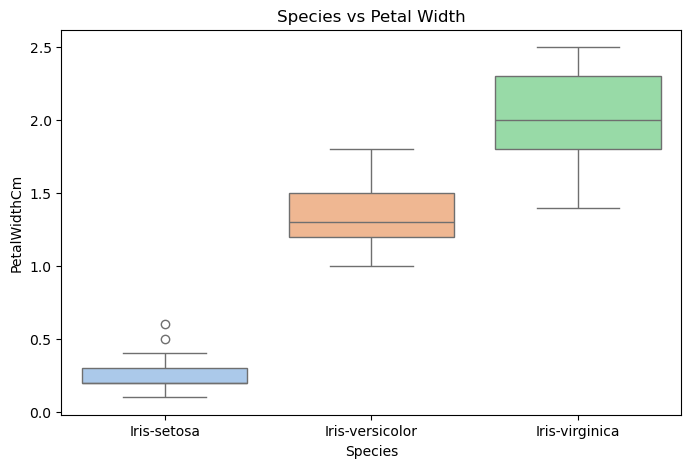

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Species',
    y='PetalWidthCm',
    data=df,
    palette='pastel',
)

plt.title("Species vs Petal Width")

plt.show()

## Label Encoding

In [16]:
# Encode Target Column

le = LabelEncoder()

df['Species'] = le.fit_transform(
    df['Species']
)

## Correlation Heatmap

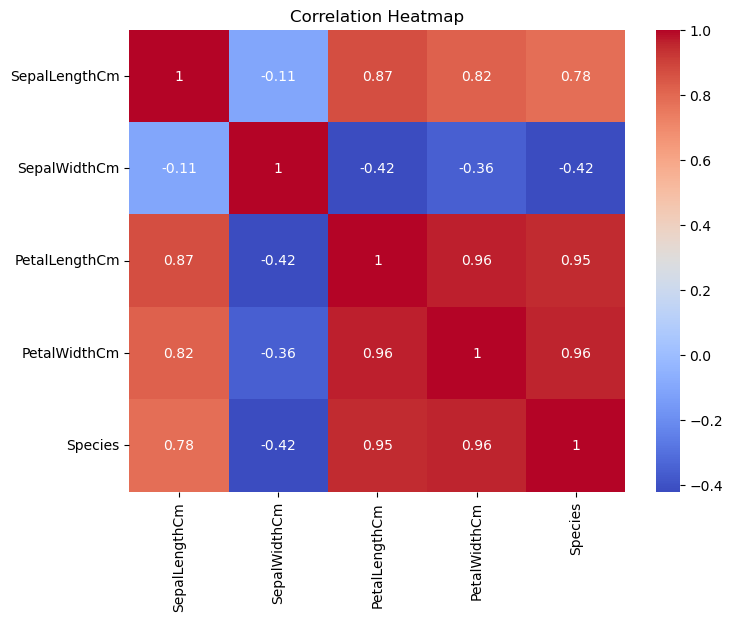

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

#### Observation
- Petal length and petal width have strong correlation with species.

## Feature Selection

In [18]:
# Features

X = df.drop(
    'Species',
    axis=1
)

# Target

y = df['Species']

## Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=0
)

## Logistic Regression

In [20]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

### Evaluation

In [21]:
print("Logistic Regression Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

Logistic Regression Accuracy:
1.0


## KNN Means

In [22]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test
)

### Evaluation

In [23]:
print("KNN Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_knn
    )
)

KNN Accuracy:
0.9666666666666667


## Random Forest Classifier

In [24]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

### Evaluation

In [25]:
print("Random Forest Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy:
1.0


## Cross validation

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("Average Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average Accuracy:
0.9666666666666668


## Model Comparison

In [27]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.000000
1,KNN,0.966667
2,Random Forest,1.000000


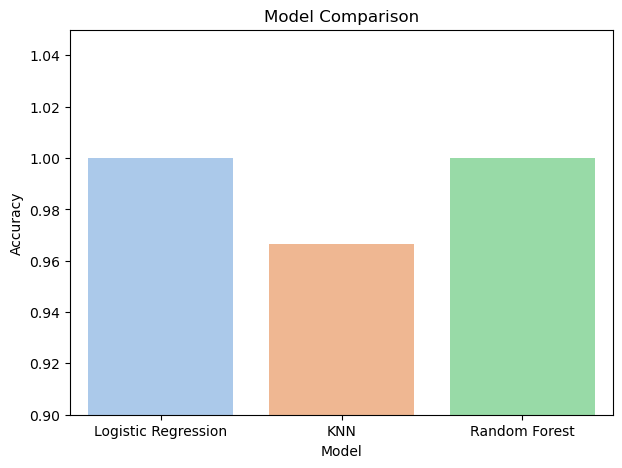

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results,
    palette = 'pastel'
)

plt.title("Model Comparison")

plt.ylim(0.9,1.05)

plt.show()

#### Observation
- Logistic Regression and Random Forest achieved 100% accuracy on the test dataset.
- KNN achieved an accuracy of 96.67%.
- Since Logistic Regression achieved perfect accuracy with lower complexity and better interpretability, it was selected as the final model.

## Confusion Matrix(Best Model)

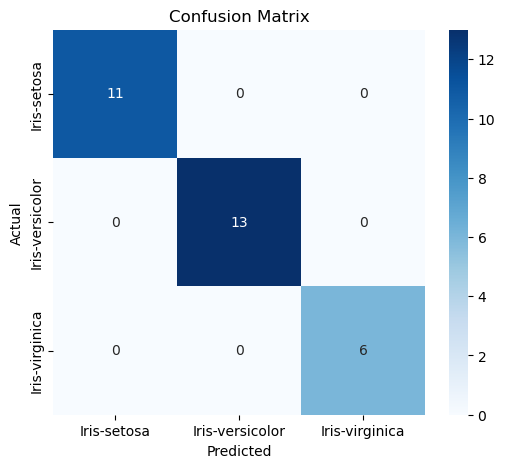

In [29]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
   cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [30]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Feature Importance

In [31]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':rf.feature_importances_
})

importance.sort_values(

    by='Importance',

    ascending=False
)
importance

,Feature,Importance
0,SepalLengthCm,0.112103
1,SepalWidthCm,0.025904
2,PetalLengthCm,0.432242
3,PetalWidthCm,0.429752


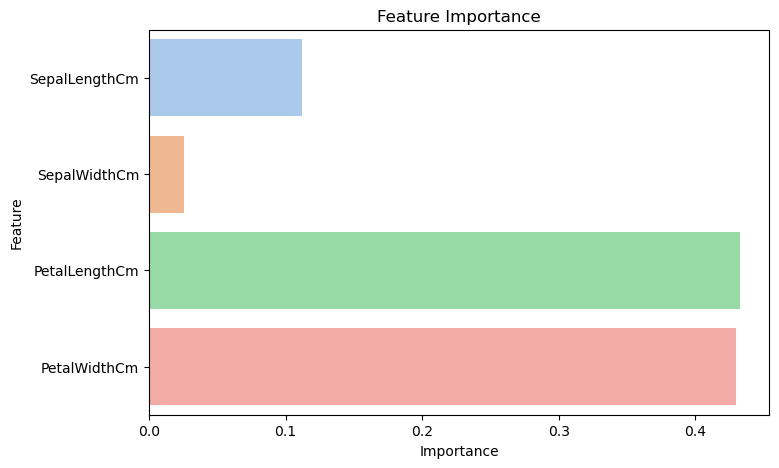

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance,

    palette='pastel'  
)

plt.title(
    "Feature Importance"
)

plt.show()

## Conclusion

1. Successfully classified Iris flower species using machine learning.
2. Performed complete data cleaning, EDA, and preprocessing.
3. Compared Logistic Regression, KNN, and Random Forest models.
4. Logistic Regression and Random Forest achieved 100% accuracy.
5. Logistic Regression was selected as the final model due to its simplicity, interpretability, and excellent performance.
6. Petal Length and Petal Width were found to be the most influential features for species classification.

## Future Improvements
1. Use cross-validation for robust evaluation.
2. Perform hyperparameter tuning.
3. Deploy the model using Streamlit.
4. Test additional classification algorithms.